# Data Preprocessing

In [ ]:
pip install -U pymoo --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install ucimlrepo --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install fairlearn --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install fairlearn matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install EMP-PY --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import xgboost as xgb
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)
warnings.filterwarnings("ignore")

In [ ]:
from ucimlrepo import fetch_ucirepo

# import German dataset (https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data)
statlog_german_credit_data = fetch_ucirepo(id=144)

# data (as df)
X = statlog_german_credit_data.data.features
y = statlog_german_credit_data.data.targets # name: "class" 1: good, 2: bad

# sample 50% of data (for performance)
# X = X.sample(frac=0.5) # use 50% of rows
# y = y.iloc[X.index]

print(X.shape)
print(y.shape)

# rename columns
X.rename(columns={"Attribute1": "Acc_Status", # for encoding:
                   "Attribute2": "Duration",
                   "Attribute3": "Cred_Hist",
                   "Attribute4": "Purpose",
                   "Attribute5": "Cred_Amount",
                   "Attribute6": "Savings_Acc",
                   "Attribute7": "Pres_Empl_Since",
                   "Attribute8": "Installm_Rate_Perc_Income",
                   "Attribute9": "Pers_Stat_Sex",
                   "Attribute10": "Other_Debtors",
                   "Attribute11": "Pres_Resid_Since",
                   "Attribute12": "Property",
                   "Attribute13": "Age",
                   "Attribute14": "Other_Inst_Plans",
                   "Attribute15": "Housing",
                   "Attribute16": "Num_Exist_Cred",
                   "Attribute17": "Job",
                   "Attribute18": "Num_People_Maint_For",
                   "Attribute19": "Telephone",
                   "Attribute20": "Foreign_Worker"},
                    inplace=True)

# convert target to binary
y.replace(1, 0, inplace=True)
y.replace(2, 1, inplace=True)

X.head()

(1000, 20)
(1000, 1)


,Acc_Status,Duration,Cred_Hist,Purpose,Cred_Amount,Savings_Acc,Pres_Empl_Since,Installm_Rate_Perc_Income,Pers_Stat_Sex,Other_Debtors,Pres_Resid_Since,Property,Age,Other_Inst_Plans,Housing,Num_Exist_Cred,Job,Num_People_Maint_For,Telephone,Foreign_Worker
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201


## TE

In [ ]:
### target encoding ###

# put X & y together
df = pd.concat([X, y], axis=1)

target_mean = df.groupby('Cred_Hist')['class'].mean()
df['Cred_Hist_TE'] = df['Cred_Hist'].map(target_mean)

# loop through all categorical variables in df
for col in df.select_dtypes(include='object'):
    target_mean = df.groupby(col)['class'].mean()
    df[col + '_TE'] = df[col].map(target_mean)
    # drop original col
    df.drop(col, axis=1, inplace=True)

print(df.shape)
df.head()

(1000, 21)


,Duration,Cred_Amount,Installm_Rate_Perc_Income,Pres_Resid_Since,Age,Num_Exist_Cred,Num_People_Maint_For,class,Cred_Hist_TE,Acc_Status_TE,Purpose_TE,Savings_Acc_TE,Pres_Empl_Since_TE,Pers_Stat_Sex_TE,Other_Debtors_TE,Property_TE,Other_Inst_Plans_TE,Housing_TE,Job_TE,Telephone_TE,Foreign_Worker_TE
0,6,1169,4,4,67,2,1,0,0.170648,0.492701,0.221429,0.174863,0.252964,0.266423,0.299890,0.212766,0.275184,0.260870,0.295238,0.279703,0.307373
1,48,5951,2,2,22,1,1,1,0.318868,0.390335,0.221429,0.359867,0.306785,0.351613,0.299890,0.212766,0.275184,0.260870,0.295238,0.313758,0.307373
2,12,2096,2,3,49,1,2,0,0.170648,0.116751,0.440000,0.359867,0.224138,0.266423,0.299890,0.212766,0.275184,0.260870,0.280000,0.313758,0.307373
3,42,7882,2,4,45,1,2,0,0.318868,0.492701,0.320442,0.359867,0.224138,0.266423,0.192308,0.306034,0.275184,0.407407,0.295238,0.313758,0.307373
4,24,4870,3,4,53,2,2,1,0.318182,0.492701,0.380342,0.359867,0.306785,0.266423,0.299890,0.435065,0.275184,0.407407,0.295238,0.313758,0.307373


In [ ]:
# encode categorical vars (instead of TE)
# X = pd.get_dummies(X)

# X.head()

In [ ]:
from sklearn.model_selection import train_test_split

# split df to X, y
X = df.drop('class', axis=1)
y = df['class']

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train.shape, y_train.shape)

(700, 20) (700,)


# Optimization

In [ ]:
# %%time
# import xgboost as xgb
# from xgboost import XGBClassifier
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import accuracy_score, make_scorer
# from EMP.metrics import empCreditScoring

# ### GRID SEARCH ###

# # Step 1 #
# clf = XGBClassifier().fit(X_train, y_train)
# y_pred_proba = clf.predict_proba(X_test)[:, 1]

# # Step 2: Define the XGBoost model
# model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# # Step 3: Define the parameter grid
# param_grid = {
#     'n_estimators': [50, 100, 200],  # Number of trees
#     'learning_rate': [0.01, 0.1, 0.2],  # Step size shrinkage
#     'max_depth': [3, 4, 5],  # Maximum tree depth
#     'subsample': [0.8, 1.0],  # Subsample ratio of training instances
#     'colsample_bytree': [0.8, 1.0],  # Subsample ratio of columns
#     'gamma': [0, 1, 5],  # Minimum loss reduction
# }

# scores = y_pred_proba
# classes = y_test.values
# emp_score = empCreditScoring(scores, classes, rounding=3)[0]

# emp_scorer = make_scorer(emp_score, needs_proba=True, greater_is_better=True)

# # Step 4: Define GridSearchCV
# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     scoring='accuracy',
#     # scoring=emp_scorer,
#     cv=5,  # 5-fold cross-validation
#     verbose=1,
#     n_jobs=-1
# )

# # Step 5: Fit the model
# grid_search.fit(X_train, y_train)

# # Step 6: Evaluate the best model
# best_model = grid_search.best_estimator_
# y_pred = best_model.predict(X_test)
# accuracy = accuracy_score(y_test, y_pred)

# # XGB Best Parameters: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.8}
# print(f"Best Parameters: {grid_search.best_params_}")
# print(f"Test Accuracy: {accuracy:.4f}")

In [ ]:
# %%time

# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import GridSearchCV

# ### RF Grid Search ###
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# grid_search = GridSearchCV(estimator=RandomForestClassifier(),
#                            param_grid=param_grid,
#                            cv=5,  # Number of cross-validation folds
#                            scoring='accuracy',  # Metric to optimize
#                            verbose=2,  # Print progress
#                            n_jobs=-1)  # Use all available cores


# grid_search.fit(X_train, y_train)

# print("Best Parameters:", grid_search.best_params_) # [max_depth= 10, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 100]
# print("Best Score:", grid_search.best_score_)

# rf_params = grid_search.best_params_
# # rf_params_list = [max_depth= 10, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 100]

# rf_params

## EMP

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from EMP.metrics import empCreditScoring

### EMP func ###
def emp_func(no_of_features, direction="forward"):
  # FS
  fs = SequentialFeatureSelector(LogisticRegression(), n_features_to_select=no_of_features,
                                 direction=direction)
  fs.fit(X_train, y_train)
  X_train_new = fs.transform(X_train)
  X_test_new = fs.transform(X_test)

  # print("Features selected: ", fs.get_feature_names_out())

  # train classification model with selected features
  clf = XGBClassifier(colsample_bytree= 1.0, gamma= 0, learning_rate= 0.1, max_depth= 5, n_estimators= 50, subsample= 0.8).fit(X_train_new, y_train) # params based on acc

  scores = clf.predict_proba(X_test_new)[:, 1] # y_pred_proba
  classes = y_test.values

  emp_score = empCreditScoring(scores, classes, rounding=3) # Will print and return output with k decimal points

  print("number of features: ", no_of_features, ", EMP: ", emp_score)

  return emp_score[0]

In [ ]:
emp_func(3)

number of features:  3 , EMP:  output(EMPC=0.025, EMPC_fraction=0.208)


0.025

In [ ]:
%%time

# create results dict
results_emp = {}

for i in range(1, len(X.columns)):
  results_emp[i] = emp_func(i)

# print(results_emp)

# converto to pd Series
df_res_emp = pd.Series(results_emp)

df_res_emp.head()

number of features:  1 , EMP:  output(EMPC=0.023, EMPC_fraction=0.22)
number of features:  2 , EMP:  output(EMPC=0.022, EMPC_fraction=0.22)
number of features:  3 , EMP:  output(EMPC=0.025, EMPC_fraction=0.208)
number of features:  4 , EMP:  output(EMPC=0.036, EMPC_fraction=0.183)
number of features:  5 , EMP:  output(EMPC=0.036, EMPC_fraction=0.18)
number of features:  6 , EMP:  output(EMPC=0.038, EMPC_fraction=0.176)
number of features:  7 , EMP:  output(EMPC=0.038, EMPC_fraction=0.178)
number of features:  8 , EMP:  output(EMPC=0.041, EMPC_fraction=0.188)
number of features:  9 , EMP:  output(EMPC=0.04, EMPC_fraction=0.186)
number of features:  10 , EMP:  output(EMPC=0.042, EMPC_fraction=0.142)
number of features:  11 , EMP:  output(EMPC=0.042, EMPC_fraction=0.169)
number of features:  12 , EMP:  output(EMPC=0.042, EMPC_fraction=0.144)
number of features:  13 , EMP:  output(EMPC=0.041, EMPC_fraction=0.171)
number of features:  14 , EMP:  output(EMPC=0.042, EMPC_fraction=0.159)
numbe

1    0.023
2    0.022
3    0.025
4    0.036
5    0.036
dtype: float64

## Fairness

In [ ]:
from fairlearn.metrics import MetricFrame
from fairlearn.metrics import selection_rate
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

### Fairness Function ###
# https://fairlearn.org/v0.10/quickstart.html

def fair_func(no_of_features): # !!! fix fairness calc

  # FS: SFS
  fs = SequentialFeatureSelector(LogisticRegression(), n_features_to_select=no_of_features)
  fs.fit(X_train, y_train)

  # create new X_train and X_test based on selected features
  X_train_new = fs.transform(X_train)
  X_test_new = fs.transform(X_test)
  # print("Features selected: ", fs.get_feature_names_out())

  # classification
  #clf = XGBClassifier(colsample_bytree= 1.0,
  #                    gamma= 0,
  #                    learning_rate= 0.1,
  #                max_depth= 5,
  #                    n_estimators= 50,
  #                    subsample= 0.8)
  clf = RandomForestClassifier() # as otherwise fairness score always same
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)

  mf = MetricFrame(metrics=accuracy_score, # [selection_rate, accuracy_score]
                  y_true=y_test,
                  y_pred=y_pred,
                  sensitive_features=X_test["Age"] # A6 seems to be some kind of grouping # can be categorical
                  )

  fair_score = mf.overall.round(3)
  # fair_score_group = mf.by_group

  print("number of features: ", no_of_features, ", fairness: ", fair_score)

  return fair_score

fair_func(3)

number of features:  3 , fairness:  0.757


0.757

In [ ]:
fair_func(3)

number of features:  3 , fairness:  0.763


0.763

In [ ]:
%%time

# create results dict
results_fair = {}

for i in range(1, len(X.columns)):
  results_fair[i] = fair_func(i)

# print(results_emp)

# converto to pd Series
df_res_fair = pd.Series(results_fair)

df_res_fair.head()

number of features:  1 , fairness:  0.79
number of features:  2 , fairness:  0.753
number of features:  3 , fairness:  0.76
number of features:  4 , fairness:  0.743
number of features:  5 , fairness:  0.77
number of features:  6 , fairness:  0.767
number of features:  7 , fairness:  0.76
number of features:  8 , fairness:  0.767
number of features:  9 , fairness:  0.757
number of features:  10 , fairness:  0.75
number of features:  11 , fairness:  0.77
number of features:  12 , fairness:  0.777
number of features:  13 , fairness:  0.763
number of features:  14 , fairness:  0.763
number of features:  15 , fairness:  0.757
number of features:  16 , fairness:  0.767
number of features:  17 , fairness:  0.763
number of features:  18 , fairness:  0.75
number of features:  19 , fairness:  0.77
CPU times: total: 2min 29s
Wall time: 2min 46s


1    0.790
2    0.753
3    0.760
4    0.743
5    0.770
dtype: float64

# 1-Obj

In [ ]:
emp_scores = df_res_emp.tolist()

# max value from results dict/list
max_emp = max(emp_scores) # emp_scores, df_res_emp, results_emp
max_emp_ind = emp_scores.index(max(emp_scores))+1
max_emp_perc = round(max_emp_ind/(len(emp_scores)+1), 2)*100

print("maximum EMP: ", max_emp, ", ", max_emp_ind, "/", len(emp_scores)+1,
      " features used(", max_emp_perc,"%)")
print("fairness w/ max.EMP feature count:", results_fair[max_emp_ind])
print("CPU time: ")

maximum EMP:  0.043 ,  18 / 20  features used( 90.0 %)
fairness w/ max.EMP feature count: 0.75
CPU time: 


In [ ]:
%%time
emp_func(max_emp_ind)

number of features:  18 , EMP:  output(EMPC=0.043, EMPC_fraction=0.143)
CPU times: total: 15.1 s
Wall time: 15.5 s


0.043

Text(0, 0.5, 'EMP')

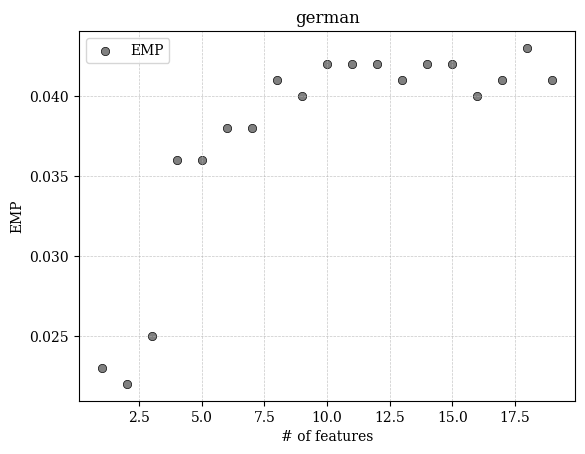

In [ ]:
# TODO: format maximum value (solution)
# TODO: add data labels for max
# TODO: add AUC and/or Acc on plot

# Scatterplot EMP - # Features
sns.scatterplot(x=range(1, len(X_train.columns)), y=df_res_emp, label="EMP", color = "grey", edgecolor="black")

# add second axis to plot
# ax2 = plt.twinx()
# sns.scatterplot(x=range(1, len(X_train.columns)), y=df_res_auc, label="AUC", color="orange", ax=ax2, alpha=0.5, s=20) # size=
# sns.scatterplot(x=range(1, len(X_train.columns)), y=df_res_acc, label="Acc", color="green", ax=ax2, alpha=0.2)

plt.grid(True, which="both", axis="both", linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend() #loc="upper left"
plt.title('german')
plt.xlabel('# of features')
plt.ylabel('EMP')

# 2-Obj

In [ ]:
from pymoo.problems.functional import FunctionalProblem

# problem def & opti, plot
max_n_features = max(results_emp.keys())

def restrain_integer_sampling(n_features):
  if n_features > max_n_features:
    return max_n_features
  elif n_features < 1:
    return 1
  else:
    return n_features

def calculate_emp(n_features):
  return -1*results_emp[n_features]

def minimize_n_features(n_features):
  return n_features

def maximize_fairness(n_features):
  return -1*results_fair[n_features]

In [ ]:
# With IntegerRandomSampling
objs = [
    lambda x: calculate_emp(restrain_integer_sampling(abs(int(x[0])))),
    lambda x: minimize_n_features(restrain_integer_sampling(abs(int(x[0])))),
    # lambda x: maximize_fairness(restrain_integer_sampling(abs(int(x[0]))))
]

n_var = 1

problem = FunctionalProblem(
    n_var,
    objs,
    # constr_ieq=constr_ieq,
    xl=np.array([1]),
    xu=np.array([5]),
    vtype=[int, int]
)

N_features_to_try = [3]  # Integer Random Sampling

F = problem.evaluate(np.array(N_features_to_try).reshape(len(N_features_to_try), 1)) # convert from (1) to (1, 1)

print(f"F: {F}\n")

F: [[-0.025  3.   ]]



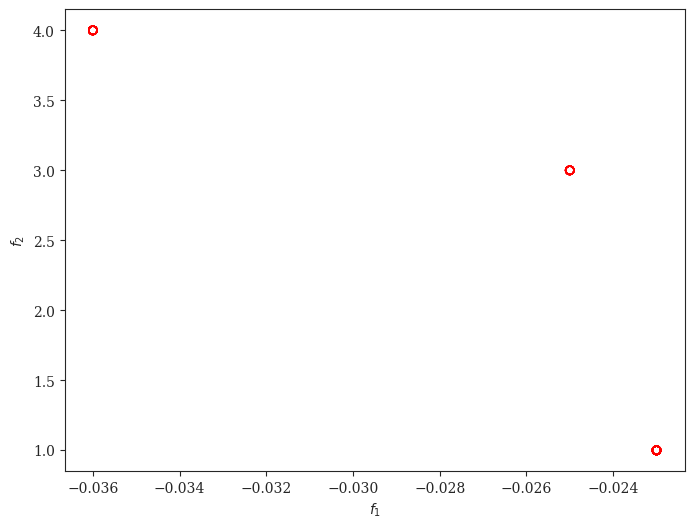

In [ ]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
from pymoo.operators.crossover.sbx import SimulatedBinaryCrossover
from pymoo.operators.mutation.pm import PolynomialMutation

algorithm = NSGA2(
    pop_size=100,
    sampling = IntegerRandomSampling(),
    crossover=SimulatedBinaryCrossover(eta=15, prob=0.9),
    mutation=PolynomialMutation(),
    eliminate_duplicates=True
  )

res = minimize(problem,
               algorithm,
               ('n_gen', 100),
               seed=1,
               verbose=False)
# Plot
plot = Scatter()
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
# plt.title("2-Obj Opti")
# plt.gca().invert_xaxis()
# plt.grid(True)

plot.show()

In [ ]:
# calculate number of features for best solution
emp_list = [abs(i) for i, j in res.F]
fs_counts = [j for i, j in res.F]

max_emp = max(emp_list)
max_fs_counts = int(max(fs_counts))
# print("Number of features:", max_fs_counts)

# Output
print("2-Obj Opti Results: ", "", sep="\n")
print("max EMP:", max_emp)
#print("AUC:", auc_func(max_fs_counts))
#print("Acc:", acc_func(max_fs_counts))
# print("CPU time: ", round(res.exec_time, 3))
print("Fairness score:", fair_func(max_fs_counts))
print ("number of features used: ", max_fs_counts)

2-Obj Opti Results: 

max EMP: 0.036
number of features:  4 , fairness:  0.77
Fairness score: 0.77
number of features used:  4


In [ ]:
%%time
emp_func(max_fs_counts)

number of features:  4 , EMP:  output(EMPC=0.036, EMPC_fraction=0.183)
CPU times: total: 7.22 s
Wall time: 3.2 s


0.036

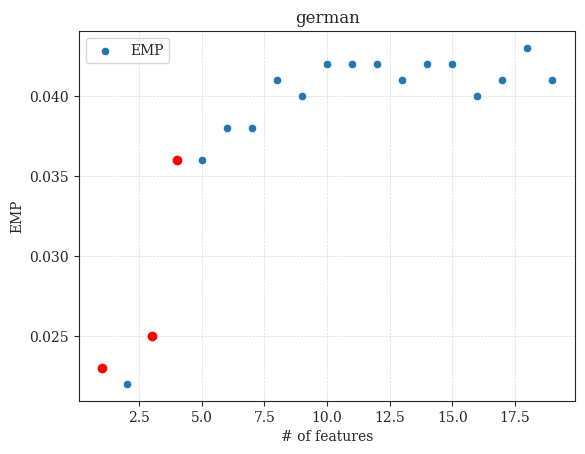

In [ ]:
### plot w/SO scatter ###

def plot_solution(X_train, df_res_emp, highlight_indices=None):
  """highilight solutions"""
  # Scatterplot EMP - # Features
  sns.scatterplot(x=range(1, len(X_train.columns)), y=df_res_emp, label="EMP")

  plt.grid(True, which="both", axis="both", linestyle='--', linewidth=0.5, alpha=0.7)
  plt.legend() #loc="upper left"
  plt.title('german')
  plt.xlabel('# of features')
  plt.ylabel('EMP')

  if highlight_indices is not None:
    # Add a single point with a different color
    # plt.scatter(highlight_indices, X_train.iloc[highlight_indices], color='red', label='Special Point')
    plt.scatter(highlight_indices, df_res_emp[highlight_indices], color='red', label='Special Point')
    pass # TODO

plot_solution(X_train, df_res_emp, np.unique(res.F[:, 1]))
# plot_solution(X_train, df_res_emp)

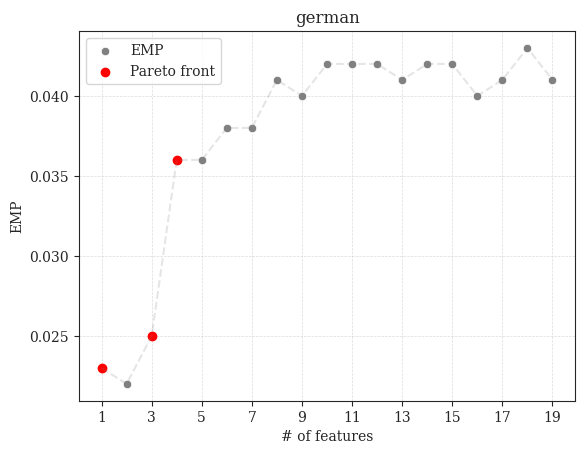

In [ ]:
### plot w/SO scatter ###

def plot_solution_2d(x, y, parameters={}, highlight_indices=None):
  """highilight solutions"""
  # Scatterplot EMP - # Features
  sns.scatterplot(x=x, y=y, label=parameters.get('label'), color='grey')
  plt.plot(x, y, linestyle='--', color='grey', alpha=0.2)  # Add connecting line
  plt.xticks(np.arange(min(x), max(x) + 1, 2))


  plt.grid(True, which="both", axis="both", linestyle='--', linewidth=0.5, alpha=0.7)

  plt.title(parameters.get('title'))
  plt.xlabel(parameters.get('x_label'))
  plt.ylabel(parameters.get('y_label'))

  if highlight_indices is not None:
    # Add a single point with a different color
    # plt.scatter(highlight_indices, X_train.iloc[highlight_indices], color='red', label='Special Point')
    plt.scatter(highlight_indices, df_res_emp[highlight_indices], color='red', label='Pareto front')

  plt.legend() #loc="upper left"

parameters = {
    'label': "EMP",
    'title': 'german',
    'x_label': '# of features',
    'y_label': 'EMP',
}
plot_solution_2d(list(range(1, len(X_train.columns))), df_res_emp, parameters, np.unique(res.F[:, 1]))
# plot_solution(X_train, df_res_emp)

# 3-Obj

In [ ]:
# With IntegerRandomSampling
objs = [
    lambda x: calculate_emp(restrain_integer_sampling(abs(int(x[0])))),
    lambda x: minimize_n_features(restrain_integer_sampling(abs(int(x[0])))),
    lambda x: maximize_fairness(restrain_integer_sampling(abs(int(x[0]))))
]

n_var = 1

problem = FunctionalProblem(
    n_var,
    objs,
    xl=np.array([1]),
    xu=np.array([5]),
    vtype=[int, int]
)

N_features_to_try = [3]  # Integer Random Sampling

F = problem.evaluate(np.array(N_features_to_try).reshape(len(N_features_to_try), 1)) # convert from (1) to (1, 1)

print(f"F: {F}\n")

F: [[-0.025  3.    -0.76 ]]



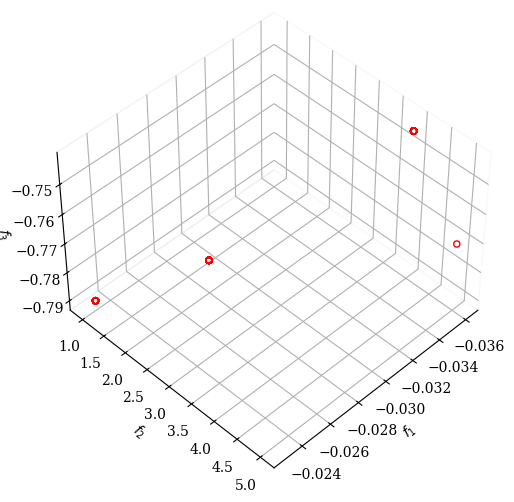

In [ ]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
from pymoo.operators.crossover.sbx import SimulatedBinaryCrossover
from pymoo.operators.mutation.pm import PolynomialMutation

algorithm = NSGA2(
    pop_size=100,
    sampling = IntegerRandomSampling(),
    crossover=SimulatedBinaryCrossover(eta=15, prob=0.9),
    mutation=PolynomialMutation(),
    eliminate_duplicates=True
  )

res = minimize(problem,
               algorithm,
               ('n_gen', 100),
               seed=1,
               verbose=False)
# Plot
plot = Scatter()
#plt.title("3-Obj Opti")
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
#plt.gca().invert_xaxis()

plot.show()

In [ ]:
# calculate number of features for best solution
emp_list = [abs(i) for i, j, k in res.F]
fs_counts = [j for i, j, k in res.F]
fair_scores = [k for i, j, k in res.F]

max_emp = max(emp_list)
max_fs_counts = int(max(fs_counts))
# print("Number of features:", max_fs_counts)

### OUTPUT ###
print("3-Obj Opti Results: ", "", sep="\n")
print("max EMP:", max_emp)
#print("AUC:", auc_func(max_fs_counts).round(3))
#print("Acc:", acc_func(max_fs_counts))
# print("CPU time: ", round(res.exec_time, 3))
print("Fairness score:", fair_func(max_fs_counts))
print ("number of features used: ", max_fs_counts)

3-Obj Opti Results: 

max EMP: 0.036
number of features:  5 , fairness:  0.773
Fairness score: 0.773
number of features used:  5


In [ ]:
%%time
emp_func(max_fs_counts)

number of features:  5 , EMP:  output(EMPC=0.036, EMPC_fraction=0.18)
CPU times: total: 3.88 s
Wall time: 3.93 s


0.036

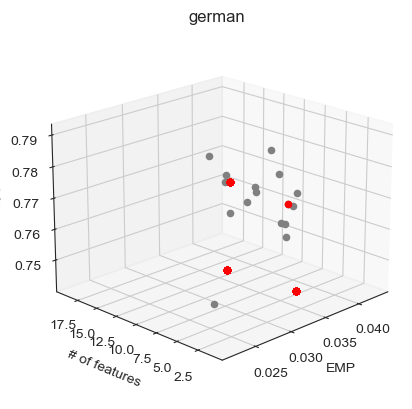

In [ ]:
def plot_solution_3d(x, y, z, point_labels, parameters={}, highlight_indices=None):
  # Create a figure and a 3D subplot
  fig = plt.figure()
  ax = fig.add_subplot(111, projection='3d')

  # Create the 3D scatter plot using Seaborn's color palette
  # darkgrid, whitegrid, dark, white, ticks
  sns.set_style("ticks") # Set Seaborn style
  # ax.scatter(x, y, z, c=z, cmap=sns.color_palette("viridis", as_cmap=True))  # Color points by z-value

  grey_idx = point_labels == "2-obj"
  red_idx = point_labels == "3-obj"
  ax.scatter(x[grey_idx], y[grey_idx], z[grey_idx], c="grey", depthshade=False)  # Color points by z-value
  ax.scatter(x[red_idx], y[red_idx], z[red_idx], c="red", depthshade=False)  # Color points by z-value
  ax.view_init(elev=20, azim=225) # Example angles

  # Set labels and title
  ax.set_xlabel(parameters.get("x_label"))
  ax.set_ylabel(parameters.get("y_label"))
  ax.set_zlabel(parameters.get("z_label"))
  ax.set_title(parameters.get("title"))

  plt.show()


# Convert results to 3D DataFrame -- 3-Obj
res_f_df = pd.DataFrame(res.F, columns=["f1", "f2", "f3"])
res_f_df = res_f_df.abs()
res_f_df["label"] = "3-obj"


# Convert the Series to 3D DataFrame - 2-Obj
df_res_emp_for_3d = pd.DataFrame(df_res_emp, columns=['f1'])  # Series to DataFrame
df_res_emp_for_3d["f2"] = range(1, len(df_res_emp)+1) # Add 'f2' column
df_res_emp_for_3d["f3"] = df_res_fair # Add 'f3' column
df_res_emp_for_3d["label"] = "2-obj"
df_res_emp_for_3d = df_res_emp_for_3d[["f1", "f2", "f3", "label"]]

merged_results = pd.concat([res_f_df, df_res_emp_for_3d], axis=0)

# res_f_df_1st_dim = res_f_df.iloc[:, 0]
# res_f_df_2nd_dim = res_f_df.iloc[:, 1]
# res_f_df_3rd_dim = res_f_df.iloc[:, 2]

df_1st_dim = merged_results.iloc[:, 0]
df_2nd_dim = merged_results.iloc[:, 1]
df_3rd_dim = merged_results.iloc[:, 2]
df_point_labels = merged_results.iloc[:, 3]

plot_solution_3d(
    x=df_1st_dim,
    y=df_2nd_dim,
    z=df_3rd_dim,
    point_labels=df_point_labels,
    parameters={'label': "EMP", 'title': 'german', 'x_label': 'EMP', 'y_label': '# of features', 'z_label': 'fairness'}
)

# all feats

In [ ]:
%%time

# CPU time
emp_func(len(X.columns)-1)

number of features:  19 , EMP:  output(EMPC=0.041, EMPC_fraction=0.188)
CPU times: total: 15.4 s
Wall time: 14.9 s


0.041

In [ ]:
%%time

print("EMP with all features:", results_emp[max(results_emp.keys())])
print("# features used: ", len(X_train.columns))
print("Fairness with all feats:", results_fair[max(results_emp.keys())])
print("CPU time:", "(check cell above)")

EMP with all features: 0.041
# features used:  20
Fairness with all feats: 0.77
CPU time: (check cell above)
CPU times: total: 0 ns
Wall time: 0 ns
